# 📁 PREPARACIÓN DEL DATASET

---

## Objetivo de este notebook

Este notebook constituye el **primer paso** del pipeline completo de detección de deepfakes. Antes de entrenar cualquier modelo de red neuronal, es imprescindible conocer el dataset a fondo: cuántas imágenes hay, si están balanceadas, si alguna está corrupta, cómo se distribuye la iluminación, etc.

Un dataset mal preparado produce modelos con sesgos ocultos que no se detectan hasta que el modelo falla en producción. Este notebook previene ese problema.

---

## 📦 Tabla de Librerías Utilizadas

| Librería | Módulo/Submódulo | Versión recomendada | ¿Para qué se usa en este proyecto? | ¿Por qué esta y no otra? |
|---|---|---|---|---|
| `torch` | `torch`, `torch.nn`, `torch.optim` | ≥ 2.0 | Framework principal de Deep Learning. Define el hardware (CPU/GPU) donde correrán los modelos. | PyTorch es el estándar en investigación; más flexible que TensorFlow para arquitecturas personalizadas. |
| `torchvision` | `datasets`, `models`, `transforms` | ≥ 0.15 | Proporciona modelos preentrenados (ResNet, EfficientNet…) y utilidades para cargar imágenes en lotes. | Ecosistema nativo de PyTorch; evita reescribir pipelines de datos estándar. |
| `os` | — | stdlib | Manejo de rutas del sistema de ficheros (joins, listdirs, existencia de carpetas). | Librería estándar de Python; no requiere instalación. |
| `pandas` | `pd` | ≥ 2.0 | Crea y manipula el DataFrame con toda la metadata del dataset (ruta, split, clase, dimensiones). | Estructura tabular ideal para filtrar, agrupar y exportar el inventario a CSV. |
| `seaborn` | `sns` | ≥ 0.13 | Genera gráficos estadísticos de alta calidad (barplots, KDE plots) con muy poco código. | API de alto nivel sobre matplotlib; produce gráficas publicación-ready con una línea. |
| `matplotlib` | `pyplot` | ≥ 3.8 | Muestra grids de imágenes y es el backend sobre el que seaborn dibuja. | Librería de referencia para visualización en Python; integración nativa con Jupyter. |
| `Pillow` | `PIL.Image` | ≥ 10.0 | Abre, verifica y redimensiona imágenes. Se usa para la validación de integridad y el cálculo de brillo. | Librería de procesamiento de imágenes más usada en Python; soporta todos los formatos relevantes. |
| `tqdm` | `tqdm` | ≥ 4.66 | Muestra barras de progreso mientras se validan las ~30.000 imágenes. | Indispensable para procesos largos: sin ella no sabes si el script cuelga o simplemente tarda. |
| `numpy` | `np` | ≥ 1.26 | Convierte imágenes a arrays numéricos para calcular el brillo medio y la cara promedio. | Estándar de facto para cálculo numérico en Python; integración directa con PIL y matplotlib. |

---

## Estructura esperada del Dataset

```
Dataset_Final_Procesado/
├── train/
│   ├── real/      ← Imágenes reales de caras para entrenamiento
│   └── fake/      ← Imágenes deepfake para entrenamiento
└── test/
    ├── real/      ← Imágenes reales para evaluación final
    └── fake/      ← Imágenes deepfake para evaluación final
```

> **Nota:** Esta estructura de carpetas `split/clase` es el estándar que torchvision's `ImageFolder` espera, lo que simplifica enormemente la carga de datos en los notebooks posteriores.

## Detección del Hardware Disponible

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# Comprobar si la RTX está lista
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")
if torch.cuda.is_available():
    print(f"Modelo de GPU: {torch.cuda.get_device_name(0)}")

Entrenando en: cuda
Modelo de GPU: NVIDIA GeForce RTX 4050 Laptop GPU


**¿Qué hace esta celda?**  
Detecta si hay una GPU NVIDIA disponible y configura el `device` que PyTorch usará para todas las operaciones tensoriales del proyecto.

**¿Por qué es lo primero que se ejecuta?**  
Porque determina el entorno de ejecución para el resto del pipeline. Si `torch.cuda.is_available()` devuelve `False` cuando debería devolver `True`, hay un problema de instalación de drivers o CUDA que conviene detectar **antes** de lanzar un entrenamiento de horas.

**Librerías usadas:**
- `torch` → framework base de Deep Learning
- `torch.nn` → módulo de capas y arquitecturas de redes neuronales
- `torch.optim` → algoritmos de optimización (Adam, SGD…)
- `torchvision.datasets`, `torchvision.models`, `torchvision.transforms` → utilidades estándar para visión por computador
- `torch.utils.data.DataLoader` → carga imágenes en mini-lotes durante el entrenamiento
- `matplotlib.pyplot` → visualización
- `os` → rutas del sistema de ficheros

## Importación y configuración de rutas

Importa librerías (pandas, PIL, seaborn) y define las rutas de las carpetas.	Establece el entorno de trabajo y asegura que Python localice las 30,000 imágenes en **C:\TFG\Dataset_Final_Procesado**.

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# Definimos la ruta base 
BASE_PATH = r'C:\TFG\Dataset_Final_Procesado\Dataset_Final_Procesado'
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
TEST_PATH = os.path.join(BASE_PATH, 'test')

# Clases
classes = ['real', 'fake']

**¿Qué hace esta celda?**  
Importa todas las librerías necesarias para el análisis exploratorio del dataset y define las rutas absolutas a las carpetas de imágenes.

**¿Por qué definir las rutas como constantes en la parte superior?**  
Es una buena práctica de ingeniería de software: si el dataset se mueve de carpeta, solo hay que cambiar `BASE_PATH` en un sitio y todo el notebook sigue funcionando. Evita tener strings de rutas "mágicos" dispersos por el código.

**¿Por qué `r'C:\...'` con la `r` delante?**  
La `r` convierte el string en un *raw string*, lo que hace que las barras invertidas `\` se traten como caracteres literales y no como secuencias de escape de Python (ej: `\t` sería un tabulador sin la `r`).

**Librerías introducidas en esta celda:**
- `pandas` → manipulación tabular de datos (inventario del dataset)
- `seaborn` → gráficos estadísticos
- `PIL.Image` → apertura y validación de imágenes
- `tqdm` → barras de progreso para bucles largos

## Conteo y Validación de Integridad

Recorre cada archivo e intenta abrirlo con img.verify(). 
- **Control de calidad**: Detecta fotos corruptas o mal descargadas que harían fallar el entrenamiento a mitad de la noche.

In [2]:
data_info = []
corrupt_files = []

print("Iniciando validación de imágenes...")

for split in ['train', 'test']:
    for label in classes:
        folder_path = os.path.join(BASE_PATH, split, label)
        files = os.listdir(folder_path)
        
        # Usamos tqdm para ver la barra de progreso en VS Code
        for file in tqdm(files, desc=f"Validando {split}/{label}"):
            file_path = os.path.join(folder_path, file)
            try:
                with Image.open(file_path) as img:
                    img.verify() # Verifica que el archivo no esté truncado
                    width, height = img.size
                    data_info.append({
                        'split': split,
                        'label': label,
                        'width': width,
                        'height': height,
                        'path': file_path
                    })
            except Exception as e:
                corrupt_files.append(file_path)

df = pd.DataFrame(data_info)

if corrupt_files:
    print(f"⚠️ ¡Atención! Se encontraron {len(corrupt_files)} archivos corruptos.")
    # Opcional: print(corrupt_files)
else:
    print("✅ Todas las imágenes son válidas.")

Iniciando validación de imágenes...


Validando test/fake: 100%|██████████| 2967/2967 [00:20<00:00, 146.02it/s]

✅ Todas las imágenes son válidas.


**¿Qué hace esta celda?**  
Recorre **cada archivo** del dataset (train/test × real/fake) e intenta abrirlo y verificarlo con PIL. Por cada imagen válida, guarda su metadata en una lista. Las corruptas van a otra lista separada.

**¿Por qué es crítico este paso?**  
Un dataset de 30.000 imágenes descargadas de internet casi seguro tiene algunas corruptas: ficheros truncados a mitad de descarga, JPEGs con cabeceras dañadas, PNGs con chunks inválidos. Si no se detectan ahora, el `DataLoader` de PyTorch lanzará una excepción aleatoria a mitad del entrenamiento (quizás a las 3 de la mañana), invalidando toda la ejecución.

**Anatomía del bucle:**
- **`tqdm(files, desc=...)`** → envuelve la lista de archivos para mostrar una barra de progreso con el label del split y clase actual.
- **`Image.open(...) as img: img.verify()`** → `verify()` lee el fichero completo y comprueba que la firma y los chunks son válidos. Es más riguroso que simplemente abrirlo.
- **`img.size`** → devuelve `(width, height)` en píxeles. Se guarda para el análisis de dimensiones posterior.
- **`try/except`** → captura cualquier excepción de PIL (IOError, SyntaxError, etc.) y añade el archivo problemático a `corrupt_files` sin interrumpir el bucle.

**Resultado:**  
Al final se construye un `DataFrame` de pandas con una fila por imagen válida, que será la fuente de verdad para todos los análisis siguientes.

## Resumen Estadístico y Gráfica

Agrupa los datos por etiqueta (real/fake) y genera un gráfico de barras.	
- Balanceo: Demuestra visualmente que el dataset está equilibrado (50/50), algo vital para evitar sesgos en la IA.


--- RESUMEN DEL DATASET ---
   split label  count
0   test  fake   2967
1   test  real   3000
2  train  fake  11932
3  train  real  12000


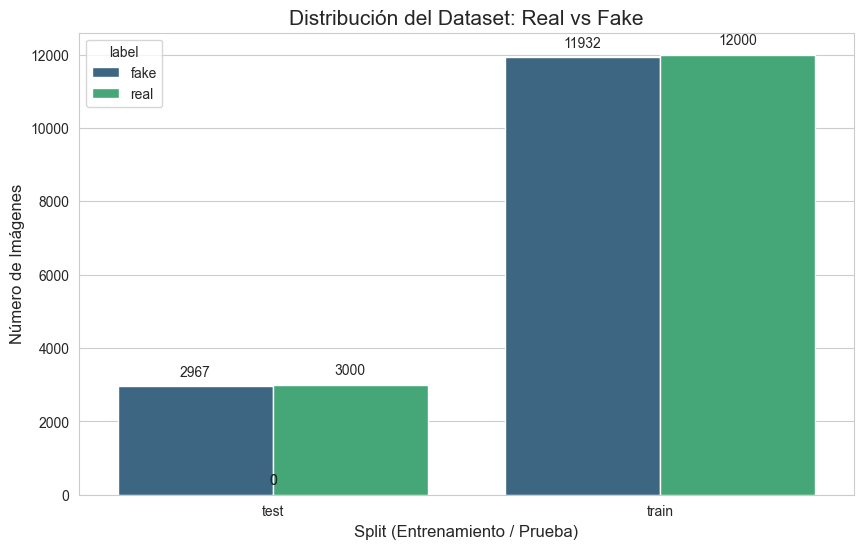

In [4]:
# Resumen numérico
summary = df.groupby(['split', 'label']).size().reset_index(name='count')
print("\n--- RESUMEN DEL DATASET ---")
print(summary)

# Gráfico de barras profesional
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=summary, x='split', y='count', hue='label', palette='viridis')

plt.title('Distribución del Dataset: Real vs Fake', fontsize=15)
plt.xlabel('Split (Entrenamiento / Prueba)', fontsize=12)
plt.ylabel('Número de Imágenes', fontsize=12)

# Añadir etiquetas de texto sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.savefig('C:/TFG/resultados/distribucion_dataset.png') # Se guarda automáticamente
plt.show()

**¿Qué hace esta celda?**  
Agrupa el DataFrame por `split` y `label` para contar cuántas imágenes hay en cada combinación (train/real, train/fake, test/real, test/fake) y lo visualiza como un gráfico de barras.

**¿Por qué verificar el balance del dataset?**  
Un dataset desbalanceado (ej: 80% real, 20% fake) produce modelos con **sesgo de clase**: el modelo aprende a predecir siempre la clase mayoritaria y obtiene un accuracy alto pero inútil. Para detección de deepfakes, necesitamos exactamente 50/50.

**Decisiones técnicas:**
- **`groupby(['split', 'label']).size()`** → cuenta filas por grupo, equivalente a un `COUNT(*)` de SQL.
- **`reset_index(name='count')`** → convierte el índice jerárquico resultante en columnas normales para que `seaborn` pueda usar `x`, `y` y `hue` directamente.
- **`palette='viridis'`** → paleta perceptualmente uniforme y apta para daltónicos.
- **`ax.annotate(...)`** → añade el número exacto encima de cada barra para que la gráfica sea autoexplicativa en un informe sin necesidad de tabla adicional.
- **`plt.savefig(...)`** → guarda la figura automáticamente en la carpeta de resultados, sin necesidad de intervención manual.

## Visualización de Muestras (Grid)

Muestra una cuadrícula (grid) de fotos aleatorias de cada clase.	
- **Sanity Check**: Confirmas visualmente que los recortes de caras son correctos antes de empezar a gastar luz entrenando.

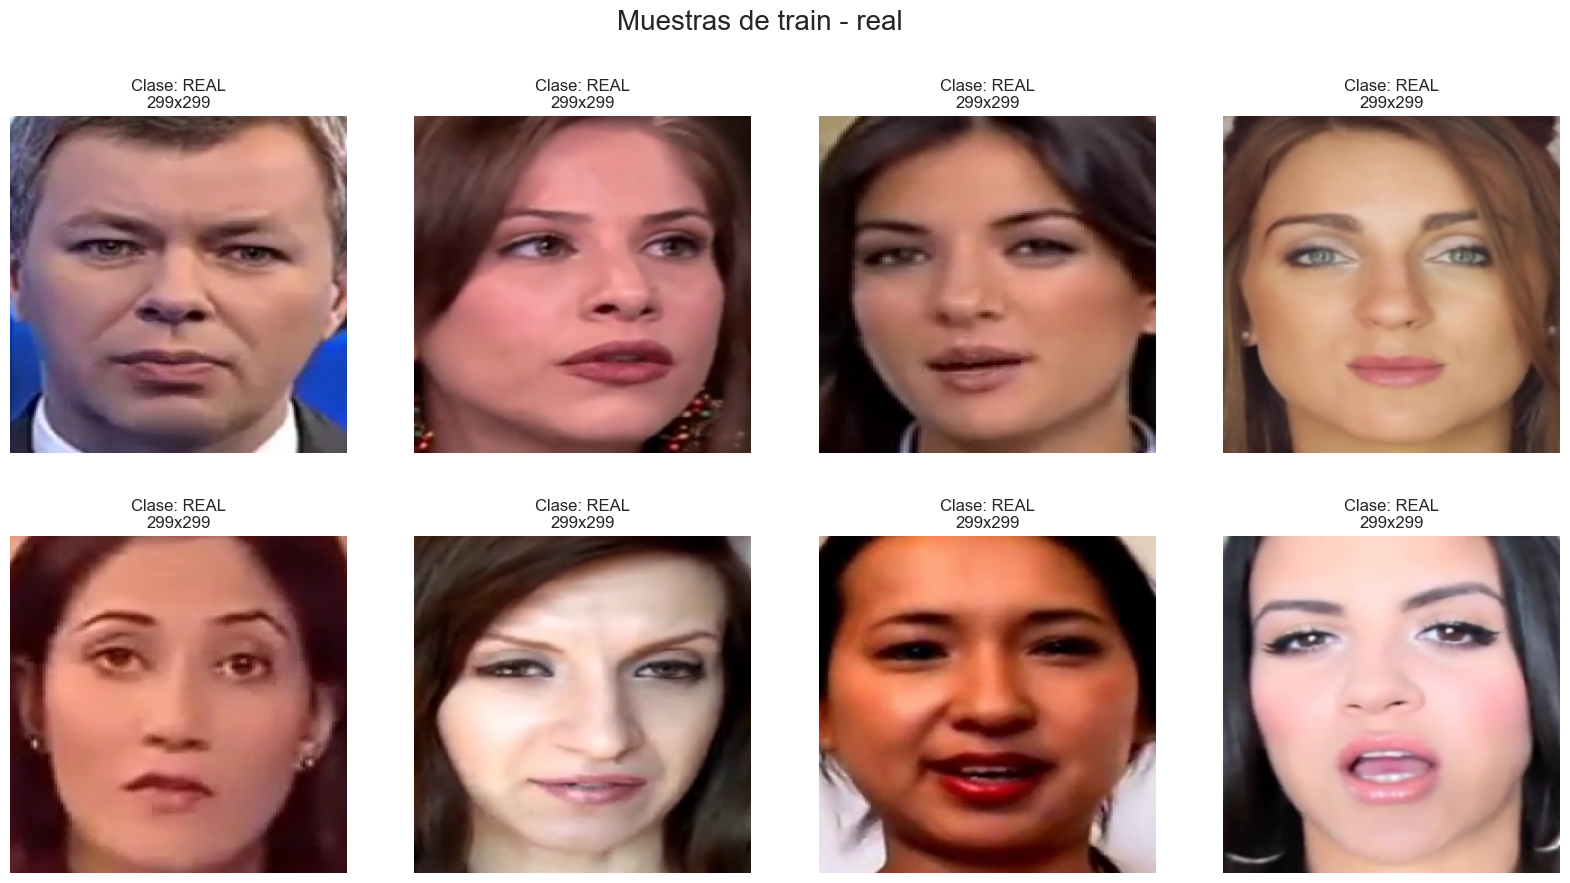

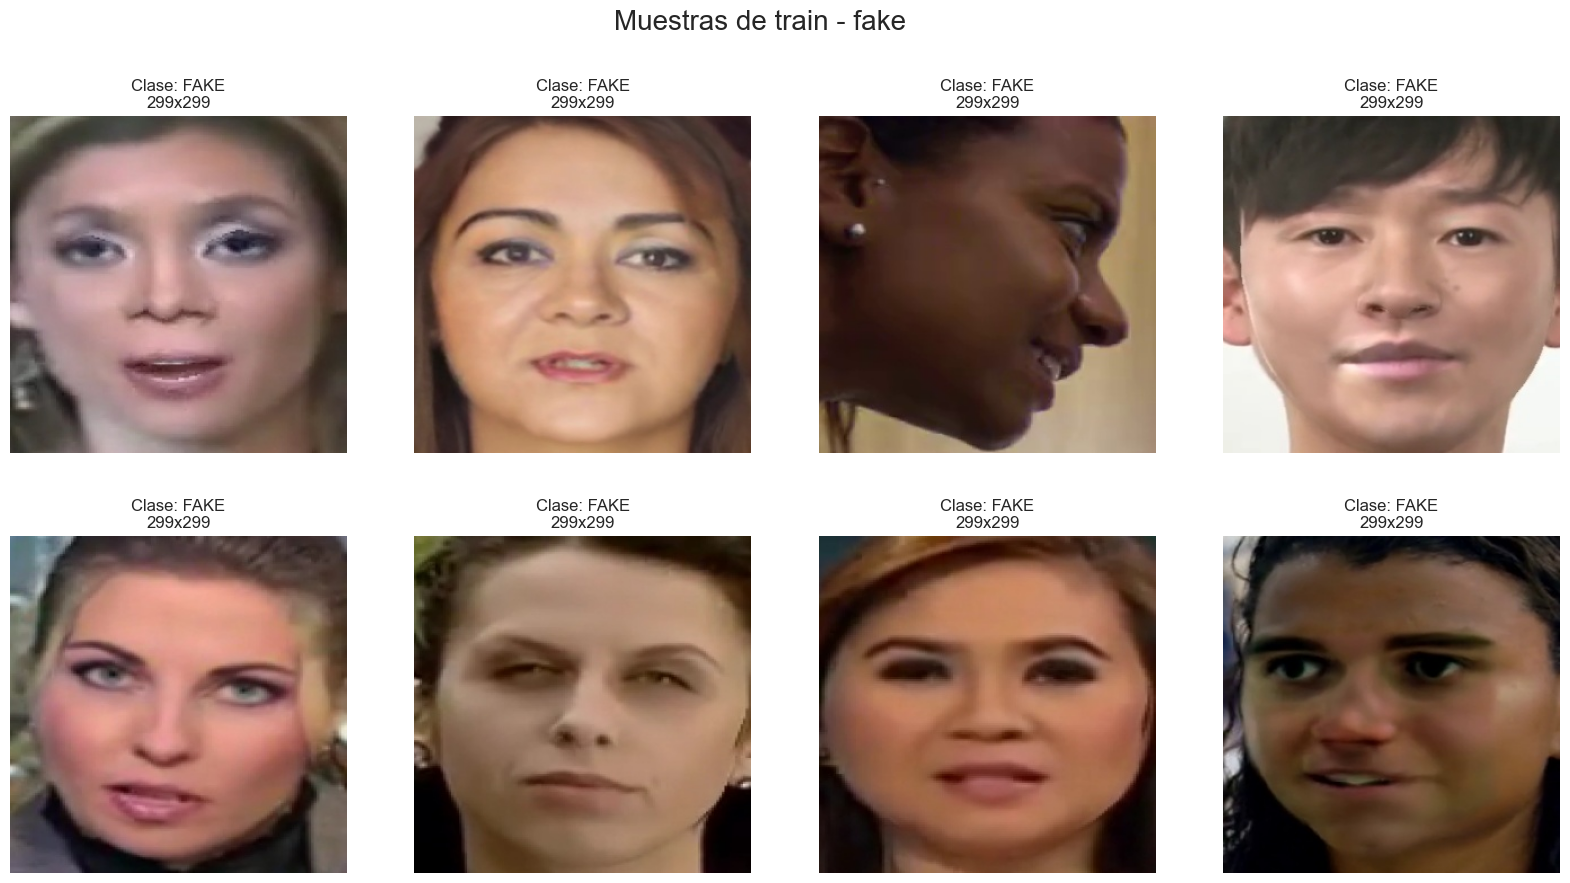

In [5]:
def show_sample_grid(dataframe, split='train', label='real', n=8):
    subset = dataframe[(dataframe['split'] == split) & (dataframe['label'] == label)].sample(n)
    
    plt.figure(figsize=(20, 10))
    for i, (_, row) in enumerate(subset.iterrows()):
        plt.subplot(2, 4, i + 1)
        img = Image.open(row['path'])
        plt.imshow(img)
        plt.title(f"Clase: {label.upper()}\n{row['width']}x{row['height']}")
        plt.axis('off')
    plt.suptitle(f"Muestras de {split} - {label}", fontsize=20)
    plt.show()

# Visualizamos Real y luego Fake
show_sample_grid(df, split='train', label='real')
show_sample_grid(df, split='train', label='fake')

**¿Qué hace esta celda?**  
Define una función reutilizable `show_sample_grid()` que muestra una cuadrícula de N imágenes aleatorias de una clase y split determinados. Se llama dos veces: una para `real` y otra para `fake`.

**¿Por qué hacer este *sanity check* visual?**  
Las métricas del dataset (número de imágenes, dimensiones) no revelan problemas cualitativos. Una inspección visual puede detectar:
- Imágenes mal recortadas (se ve más que la cara)
- Imágenes de fondo erróneamente etiquetadas como rostros
- Artefactos de compresión muy pronunciados
- Imágenes de una clase que visualmente parecen de la otra

**Decisiones técnicas:**
- **`dataframe.sample(n)`** → selección aleatoria sin reemplazo, garantizando que cada ejecución muestra imágenes distintas.
- **`plt.subplot(2, 4, i+1)`** → rejilla 2×4 = 8 imágenes por llamada, balance entre visión de conjunto y tamaño visible.
- **`plt.axis('off')`** → elimina los ejes numéricos que no aportan información en imágenes.
- **`plt.suptitle()`** → título global que abarca toda la figura (vs `plt.title()` que solo afecta al subplot activo).

## Análisis de Iluminación (Histograma de Brillo)

Que no hay un sesgo lumínico entre clases.	"Se descarta que la iluminación sea una variable predictora que induzca a error al modelo".

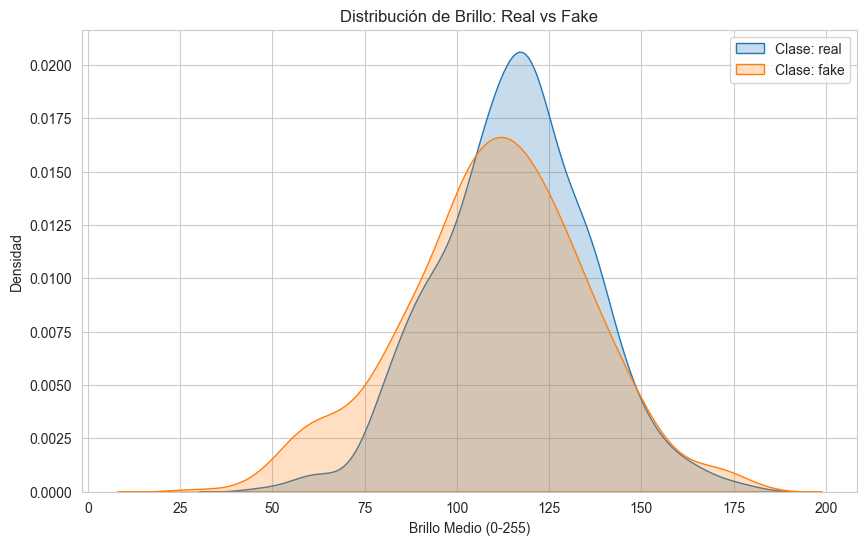

In [7]:
import numpy as np

def analyze_brightness(dataframe, n_samples=500):
    plt.figure(figsize=(10, 6))
    for label in ['real', 'fake']:
        subset = dataframe[dataframe['label'] == label].sample(n_samples)
        brightness_values = []
        
        for _, row in subset.iterrows():
            # Abrimos en escala de grises para medir brillo
            img = Image.open(row['path']).convert('L') 
            brightness_values.append(np.mean(img))
            
        sns.kdeplot(brightness_values, label=f'Clase: {label}', fill=True)

    plt.title('Distribución de Brillo: Real vs Fake')
    plt.xlabel('Brillo Medio (0-255)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.savefig('C:/TFG/resultados/analisis_brillo.png')
    plt.show()

# Ejecutar análisis
analyze_brightness(df)

**¿Qué hace esta celda?**  
Para una muestra aleatoria de imágenes de cada clase, calcula el **brillo medio** de cada imagen convirtiéndola primero a escala de grises, y luego visualiza la distribución de esos valores con un *KDE plot* (estimación de densidad kernel).

**¿Por qué analizar el brillo?**  
Es una comprobación de **sesgo de confusión**. Si las imágenes fake son sistemáticamente más oscuras o más claras que las reales, el modelo podría aprender a clasificar por brillo en lugar de por textura o artefactos de generación. Ese modelo fallaría con una foto real tomada con poca luz.

**Interpretación de resultados esperada:**  
Las dos curvas deben estar casi superpuestas (pico en ~115-120 sobre la escala 0-255), indicando que la iluminación no es un predictor confusor.

**Decisiones técnicas:**
- **`Image.open(...).convert('L')`** → convierte la imagen a escala de grises (*Luminance*). Cada píxel pasa a tener un único valor 0-255 representando su brillo.
- **`np.mean(img)`** → calcula la media de todos los píxeles, obteniendo el brillo global de esa imagen.
- **`sns.kdeplot(..., fill=True)`** → en lugar de un histograma (discreto), usamos KDE para una curva de densidad continua más legible cuando se comparan dos distribuciones en la misma gráfica.
- **`n_samples=500`** → analizar las 30.000 imágenes sería lento e innecesario; 500 por clase dan una estimación estadísticamente sólida.

### 📊 Interpretación del gráfico de brillo

Las dos curvas (azul para *real*, naranja para *fake*) están **casi solapadas**, con el pico (la moda) en valores muy próximos —aproximadamente entre 115 y 120 sobre la escala 0-255.

**¿Qué significaría si NO estuvieran solapadas?**  
Si la curva *fake* estuviera desplazada marcadamente hacia la izquierda (imágenes más oscuras), el modelo podría aprender el atajo: *"si la foto es oscura → es fake"*. Esto es un **sesgo de confusión**: el modelo no aprendería a detectar deepfakes reales, sino características accidentales del proceso de recopilación de datos.

**Observación matizable:**  
La curva *fake* es ligeramente más ancha y presenta un pequeño bulto hacia la izquierda. Esto es esperable: los deepfakes provienen a menudo de vídeos con condiciones de iluminación más variadas. Sin embargo, la diferencia es lo suficientemente pequeña como para no constituir un sesgo significativo.

**Conclusión:** La iluminación queda descartada como variable predictora espuria. El modelo deberá aprender señales más sutiles (texturas, artefactos de síntesis, inconsistencias de bordes).

## Cara Promedio (Mapa de Calor de Alineación)

Que el preprocesamiento (crop facial) fue consistente.	
"La alta definición de los rasgos en la cara promedio valida la calidad del centrado de las muestras".

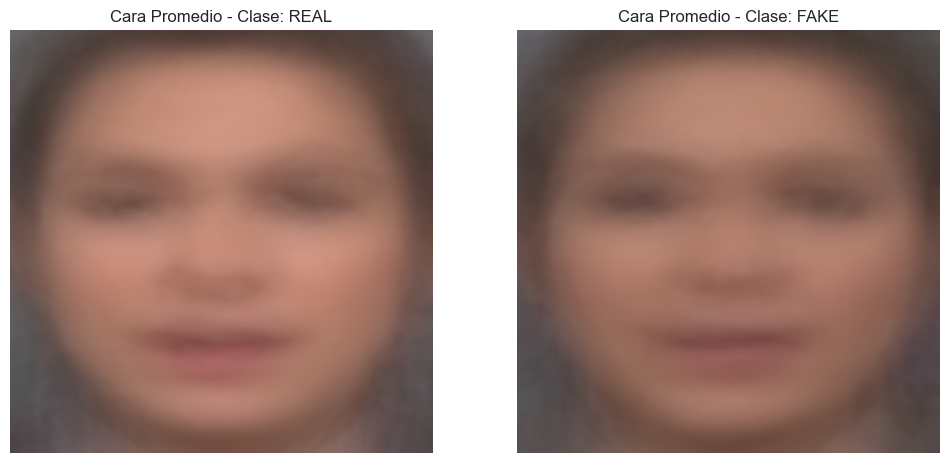

In [9]:
def plot_average_face(dataframe, label='real', n_samples=100):
    subset = dataframe[dataframe['label'] == label].sample(n_samples)
    all_imgs = []
    
    for _, row in subset.iterrows():
        img = Image.open(row['path']).convert('RGB').resize((224, 224))
        all_imgs.append(np.array(img))
        
    avg_face = np.mean(all_imgs, axis=0).astype(np.uint8)
    
    plt.imshow(avg_face)
    plt.title(f'Cara Promedio - Clase: {label.upper()}')
    plt.axis('off')

# Mostramos las dos comparadas
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_average_face(df, 'real')
plt.subplot(1, 2, 2)
plot_average_face(df, 'fake')
plt.savefig('C:/TFG/resultados/caras_promedio.png')
plt.show()

**¿Qué hace esta celda?**  
Calcula la media píxel a píxel de N imágenes de cada clase, generando una imagen *compuesta* que representa el aspecto promedio de esa clase.

**¿Por qué es una métrica de calidad del preprocesamiento?**  
Si el recorte y alineado de caras fue consistente (ojos siempre en la misma posición relativa, nariz centrada), la cara promedio mostrará rasgos nítidos y reconocibles. Si el preprocesamiento fue deficiente (caras rotadas, desplazadas o mal escaladas), el promedio resultará en un borrón informe porque los rasgos no se suman constructivamente.

**Decisiones técnicas:**
- **`.convert('RGB')`** → estandariza el modo de color (algunos JPEG vienen en CMYK o con canal alfa), garantizando que todos los arrays tengan 3 canales.
- **`.resize((224, 224))`** → redimensiona a 224×224, la resolución estándar de entrada de modelos como ResNet, EfficientNet y EfficientNetV2. Es necesario para que `np.mean()` pueda promediar arrays de la misma forma.
- **`np.array(img)`** → convierte la imagen PIL en un array NumPy de forma `(224, 224, 3)` con valores uint8.
- **`np.mean(all_imgs, axis=0).astype(np.uint8)`** → promedia a lo largo del eje 0 (el eje de las imágenes), obteniendo la media de cada canal en cada posición espacial. El `astype(np.uint8)` convierte de float64 a entero 8-bit para que matplotlib pueda mostrarlo.

### 📊 Interpretación de las caras promedio

En ambas imágenes, los ojos, la nariz y la boca deben aparecer **en la misma posición relativa** y con bordes nítidos, no como manchas borrosas.

**¿Por qué aparecen nítidas si son un promedio de 100 caras distintas?**  
Porque el preprocesamiento de detección y recorte facial alineó todas las caras: todos los ojos están aproximadamente a la misma altura, todas las narices están centradas. Al promediar, los rasgos se **refuerzan mutuamente** en lugar de cancelarse.

Si el resultado fuera un borrón sin rasgos reconocibles, indicaría que el paso de *face alignment* falló y habría que repetir el preprocesamiento antes de continuar con el entrenamiento.

**Conclusión:** La alta definición de los rasgos en ambas caras promedio **valida la calidad del pipeline de preprocesamiento** y garantiza que los modelos recibirán imágenes con el sujeto correctamente centrado.

## Guardar Registro (CSV)

Guarda la lista de imágenes válidas en un archivo .csv.	
- Rigor científico: Garantiza que los 4 modelos (ExceptionNet, etc.) se evalúen exactamente con la misma lista de archivos.

In [6]:
# Guardamos el dataframe como CSV
df.to_csv(r'C:\TFG\Dataset_Final_Procesado\registro_datos.csv', index=False)
print("Archivo 'registro_datos.csv' guardado correctamente en la carpeta data.")

Archivo 'registro_datos.csv' guardado correctamente en la carpeta data.


---

**¿Qué hace esta celda?**  
Serializa el DataFrame completo (con la ruta, clase, split y dimensiones de cada imagen válida) a un archivo CSV en disco.

**¿Por qué guardar este CSV si ya tenemos las imágenes?**  
Por **reproducibilidad y rigor científico**. Este CSV actúa como el *registro canónico* del dataset usado en el experimento:

1. **Consistencia entre modelos**: Los cuatro modelos que se entrenarán (ExceptionNet, EfficientNetV2, etc.) leerán exactamente la misma lista de archivos, sin riesgo de que cambios en el sistema de ficheros alteren el conjunto de evaluación entre ejecuciones.
2. **Trazabilidad**: Si en el futuro se detecta un problema con alguna imagen específica, se puede localizar exactamente cuándo y en qué experimento se usó.
3. **Velocidad de carga**: Futuros notebooks pueden leer este CSV (`pd.read_csv(...)`) y saltarse la validación entera, que tarda varios minutos.

**Decisiones técnicas:**
- **`index=False`** → no guarda el índice numérico del DataFrame como columna extra en el CSV. El índice es un detalle interno de pandas sin significado semántico para el proyecto.